# Introducción a Deep Learning

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana02_DL_autograd.ipynb)

## Clasificación con CNN en FashionMNIST

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import random
import matplotlib.pyplot as plt

Se desea entrenar un modelo de clasificación de imágenes sobre el dataset FashionMNIST, que consiste en imágenes en escala de grises de tamaño $28 \times 28$ pertenecientes a 10 clases de prendas de vestir. Cada ejemplo está dado por un par $(x_i, y_i)$, donde $x_i \in [0,1]^{28 \times 28}$ es la imagen normalizada y $y_i \in {0,\dots,9}$ es la etiqueta correspondiente (por ejemplo: remera, pantalón, zapatilla, etc.). 

El objetivo es aprender una función $f_\theta(x)$ que produzca una distribución de probabilidad sobre las clases, típicamente mediante una capa final con softmax: $p(y \mid x) = \text{softmax}(f_\theta(x))$. El modelo se entrena minimizando la pérdida de entropía cruzada entre las predicciones y las etiquetas reales: $ \mathcal{L} = -\sum_i \log p(y_i \mid x_i)$, utilizando minibatches para optimizar eficientemente los parámetros mediante descenso por gradiente.

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

torch.manual_seed(0)

batch_size = 128
lr = 1e-3
epochs = 10

# Datos
transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1], shape: (1,28,28)
])

train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = ["Remera","Pantalón","Pulover","Vestido","Abrigo","Sandalia","Camisa","Zapatilla","Bolso","Bota"]


cpu


### Modelo CNN

Se propone una red neuronal convolucional (CNN) para clasificar imágenes de FashionMNIST, aprovechando la estructura espacial de las imágenes. El modelo recibe como entrada tensores $x \in \mathbb{R}^{1 \times 28 \times 28}$ y aplica dos capas convolucionales: la primera transforma la entrada a 16 mapas de características manteniendo resolución espacial, y la segunda produce 32 mapas. Cada convolución es seguida por una activación no lineal $\text{ReLU}(z) = \max(0, z)$ y una operación de *max pooling* que reduce la dimensión espacial (de $28 \times 28$ a $14 \times 14$, y luego a $7 \times 7$). Luego, los mapas se aplanan en un vector y se procesan con capas totalmente conectadas: $32 \cdot 7 \cdot 7 \rightarrow 128 \rightarrow 10$, donde la salida final son *logits* $f_\theta(x) \in \mathbb{R}^{10}$. Estos logits se transforman implícitamente en probabilidades mediante softmax: $p(y \mid x) = \text{softmax}(f_\theta(x))$, y el modelo se entrena minimizando la pérdida de entropía cruzada. La métrica de desempeño es la exactitud, calculada como la proporción de predicciones correctas: $\text{acc} = \frac{1}{N} \sum_i \mathbf{1}(\hat{y}_i = y_i)$.

In [3]:
# Modelo Red Neuronal Convolucional
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14 -> 14x14
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 clases

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)         # 28x28 -> 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)         # 14x14 -> 7x7
        x = x.view(x.size(0), -1)      # flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)             # logits

model = SmallCNN().to(device)

# Pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Entrenamiento
def accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.numel()
    model.train()
    return correct / total

### Loop de entrenamiento

In [4]:
for epoch in range(1, epochs + 1):
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_ds)
    test_acc = accuracy(test_loader)

    print(f"Epoch {epoch}/{epochs} | loss: {train_loss:.4f} | test acc: {test_acc:.4f}")

Epoch 1/10 | loss: 0.5963 | test acc: 0.8302
Epoch 2/10 | loss: 0.3506 | test acc: 0.8736
Epoch 3/10 | loss: 0.3042 | test acc: 0.8890
Epoch 4/10 | loss: 0.2731 | test acc: 0.8894
Epoch 5/10 | loss: 0.2510 | test acc: 0.8973
Epoch 6/10 | loss: 0.2347 | test acc: 0.8964
Epoch 7/10 | loss: 0.2202 | test acc: 0.9062
Epoch 8/10 | loss: 0.2105 | test acc: 0.9098
Epoch 9/10 | loss: 0.1960 | test acc: 0.9131
Epoch 10/10 | loss: 0.1841 | test acc: 0.9109


### Visualización de resultados

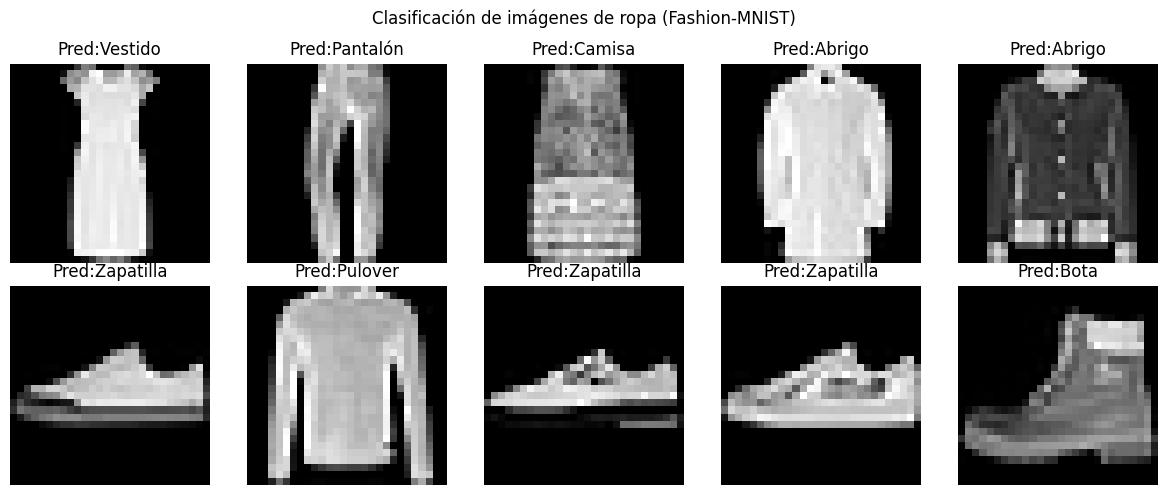

In [5]:
model.eval().cpu()

# Elegir 10 imágenes aleatorias del conjunto de test
indices = random.sample(range(len(test_ds)), 10)

plt.figure(figsize=(12, 5))

for i, idx in enumerate(indices):
    x, y_true = test_ds[idx]

    with torch.no_grad():
        logits = model(x.unsqueeze(0))
        y_pred = logits.argmax(dim=1).item()

    plt.subplot(2, 5, i + 1)
    plt.imshow(x.squeeze(), cmap="gray")
    plt.title(f"Pred:{classes[y_pred]}")
    plt.axis("off")

plt.suptitle("Clasificación de imágenes de ropa (Fashion-MNIST)")
plt.tight_layout()
plt.show()

## Regresión: Oscilador Amortiguado

In [6]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Un oscilador armónico amortiguado está gobernado por la ecuación diferencial 

$$
m \ddot{x} + c \dot{x} + k x = 0
$$,

 que puede reescribirse como $\ddot{x} + 2\gamma \dot{x} + \omega_0^2 x = 0$, donde $\gamma = \frac{c}{2m}$ es el coeficiente de amortiguamiento y $\omega_0 = \sqrt{\frac{k}{m}}$ la frecuencia natural. 

En el régimen subamortiguado ($ \gamma < \omega_0$), la solución es $ x(t) = A e^{-\gamma t} \cos(\omega t + \phi)$, con $ \omega = \sqrt{\omega_0^2 - \gamma^2}$. 

En el dataset, se generan muestras $(t_i, y_i)$ evaluando esta solución en tiempos aleatorios $t_i \in [0,10]$, y luego se agrega ruido gaussiano: $y_i = x(t_i) + \varepsilon_i$, con $ \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, simulando mediciones experimentales imperfectas.


In [7]:
# Dataset de oscilador sintético
rng = np.random.default_rng(0)

A = 1.0       # amplitud
gamma = 0.15  # amortiguamiento (γ)
omega = 2.5   # frecuencia angular (ω)
phi = 0.4     # fase (φ)

def x_true(t):
    return A * np.exp(-gamma * t) * np.cos(omega * t + phi)

N = 800
t = rng.uniform(0.0, 10.0, size=(N, 1)).astype(np.float32)
y = x_true(t).astype(np.float32)

noise_std = 0.05
y_noisy = y + noise_std * rng.normal(size=y.shape).astype(np.float32)

# Train/test split
idx = rng.permutation(N)
n_train = int(0.8 * N)
train_idx, test_idx = idx[:n_train], idx[n_train:]

t_train, y_train = t[train_idx], y_noisy[train_idx]
t_test,  y_test  = t[test_idx],  y_noisy[test_idx]

# Estandarizar entrada (t) ayuda al entrenamiento
t_mean, t_std = t_train.mean(axis=0, keepdims=True), t_train.std(axis=0, keepdims=True) + 1e-8
t_train_s = (t_train - t_mean) / t_std
t_test_s  = (t_test  - t_mean) / t_std

# Tensores
t_train_t = torch.from_numpy(t_train_s)
y_train_t = torch.from_numpy(y_train)
t_test_t  = torch.from_numpy(t_test_s)
y_test_t  = torch.from_numpy(y_test)

### Modelo MLP de regresión


Queremos ajustar un perceptrón multicapa (MLP) para aproximar la relación entre el tiempo $t$ y la posición $x(t)$ del oscilador a partir de datos ruidosos. El modelo recibe como entrada un escalar $t$ (previamente estandarizado) y produce una predicción $\hat{x}(t)$. La arquitectura consiste en una red totalmente conectada de tres capas lineales con activaciones no lineales $\tanh$, lo que le permite capturar tanto la oscilación como el decaimiento exponencial de la señal. El entrenamiento se realiza minimizando una función de pérdida (por ejemplo, MSE) entre las predicciones del modelo y las observaciones $y_i$.

In [8]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(0)
model = MLP()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### Loop de entrenamiento

In [9]:
batch_size = 128
epochs = 1500

for epoch in range(1, epochs + 1):
    # mini-batch simple
    perm = torch.randperm(t_train_t.size(0))
    for i in range(0, t_train_t.size(0), batch_size):
        idxb = perm[i:i+batch_size]
        xb = t_train_t[idxb]
        yb = y_train_t[idxb]

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

    if epoch in {1, 200, 500, 1000, 1500}:
        with torch.no_grad():
            test_pred = model(t_test_t)
            rmse = torch.sqrt(torch.mean((test_pred - y_test_t) ** 2)).item()
        print(f"Epoch {epoch:4d} | Test RMSE: {rmse:.4f}")

Epoch    1 | Test RMSE: 0.3902
Epoch  200 | Test RMSE: 0.3766
Epoch  500 | Test RMSE: 0.3245
Epoch 1000 | Test RMSE: 0.0645
Epoch 1500 | Test RMSE: 0.0517


### Visualización de los resultados

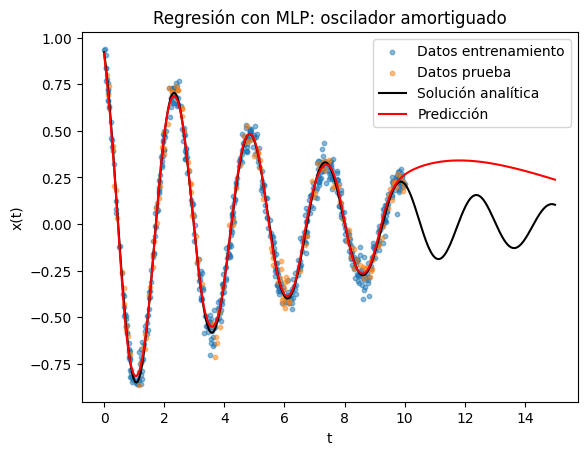

In [10]:
# Curva ordenada en el tiempo para graficar suave
t_grid = np.linspace(0.0, 10.0, 600, dtype=np.float32).reshape(-1, 1)

t_extra = np.linspace(0.0, 15.0, 700, dtype=np.float32).reshape(-1, 1)
t_extra_s = (t_extra - t_mean) / t_std

with torch.no_grad():
    y_grid_pred = model(torch.from_numpy(t_extra_s)).numpy()

plt.figure()
plt.scatter(t_train, y_train, s=10, alpha=0.5, label="Datos entrenamiento")
plt.scatter(t_test,  y_test,  s=10, alpha=0.5, label="Datos prueba")
plt.plot(t_extra, x_true(t_extra), '-', c="black", label="Solución analítica")
plt.plot(t_extra, y_grid_pred, 'r-', label="Predicción")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Regresión con MLP: oscilador amortiguado")
plt.legend()
plt.show()

## Redes Neuronales Recurrentes

Ahora, en vez de abordar este problema usando una **MLP (Perceptrón Multicapa)**, utilizaremos una Gated Recurrent Unit **GRU**, que está especialmente diseñada para trabajar con secuencias y dependencias temporales, por lo que resulta una alternativa natural para series de tiempo como ésta.

**Construiremos un dataset de ventanas temporales**, usando una longitud de contexto fija $L$, de modo que cada secuencia de entrada contenga los últimos $L$ puntos y la salida sea el siguiente valor.

In [71]:
# Usamos una ventana de longitud L para predecir el siguiente punto.
L = 80  # longitud de contexto
N = 800

def make_windows(series, L):
    X, Y = [], []
    series = series.squeeze()
    for i in range(len(series) - L):
        X.append(series[i:i+L])
        Y.append(series[i+L])
    return torch.vstack(X).unsqueeze(-1), torch.vstack(Y)

t_ordered = torch.linspace(0,10,N)
y_ordered = x_true(t_ordered)

noise_std = 0.1
y_noisy_o = y_ordered + noise_std * torch.randn(size=y_ordered.shape)

y_noisy_mean, y_noisy_std = y_noisy_o.mean(), y_noisy_o.std()

y_noisy_n = (y_noisy_o - y_noisy_mean)/y_noisy_std

X_all, y_all = make_windows(y_noisy_n, L)  # X_all: (N, L, 1), y_all: (N, 1)
print(X_all.shape, y_all.shape)

torch.Size([720, 80, 1]) torch.Size([720, 1])


Definiremos y entrenaremos una GRU para resolver el problema de regresión secuencial. En este caso, evaluaremos el error en test mediante MSE.

In [72]:
# Train/test split respetando el orden temporal
N = X_all.shape[0]
n_train = int(0.8 * N)

X_train, y_train = X_all[:n_train], y_all[:n_train]
X_test,  y_test  = X_all[n_train:], y_all[n_train:]

train_dataset = TensorDataset(X_train, y_train)
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Modelo recurrente (GRU)
class GRURegressor(nn.Module):
    def __init__(self, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (B, L, 1)
        out, _ = self.rnn(x)          # out: (B, L, H)
        h_last = out[:, -1, :]        # último estado oculto: (B, H)
        y_hat = self.head(h_last)     # (B, 1)
        return y_hat

torch.manual_seed(0)
model = GRURegressor(hidden_size=64)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Entrenamiento
epochs = 30

for epoch in range(epochs):
    model.train()
    for xb, yb in train_dataloader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

    if epoch in list(range(0,epochs,5)):
        model.eval()
        with torch.no_grad():
            pred_test = model(X_test)
            rmse = torch.sqrt(torch.mean((pred_test - y_test) ** 2)).item()
        print(f"Epoch {epoch:2d} | Test RMSE (norm): {rmse:.4f}")


Epoch  0 | Test RMSE (norm): 0.3887
Epoch  5 | Test RMSE (norm): 0.2856
Epoch 10 | Test RMSE (norm): 0.2884
Epoch 15 | Test RMSE (norm): 0.2881
Epoch 20 | Test RMSE (norm): 0.2820
Epoch 25 | Test RMSE (norm): 0.2887


Comparamos visualmente la señal con las predicciones del modelo.

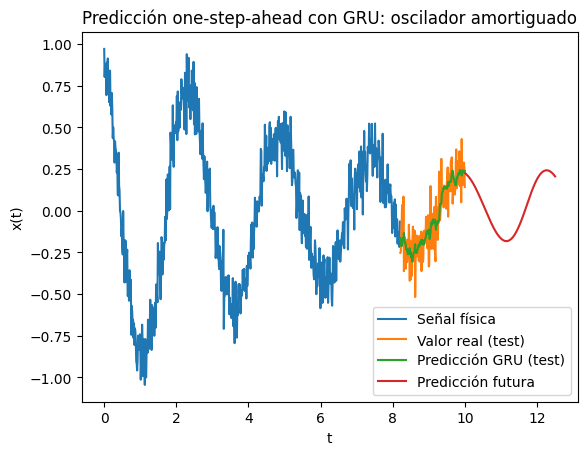

In [73]:
# Visualización: predicción vs real en el tramo de test
model.eval()
with torch.no_grad():
    yhat_test = model(X_test).squeeze(-1)  # normalizado
    y_test = y_test.squeeze(-1)

# Desnormalizar para graficar en unidades originales
yhat_test_u = yhat_test * y_noisy_std + y_noisy_mean
y_test_u    = y_test  * y_noisy_std + y_noisy_mean
y_train_u = y_train * y_noisy_std + y_noisy_mean

# Tiempo del tramo de test
t_test = t_ordered[L + n_train : L + n_train + len(y_test_u)]

ventana = y_test[-L:].unsqueeze(0).unsqueeze(-1)
preds = []
dt = (t_ordered[1:] - t_ordered[0:-1])[-1].item()
t_preds = [t_ordered[-1].item()]
with torch.no_grad():
    for i in range(200):
        y_pred = model(ventana)
        preds.append(y_pred.item())
        ventana = torch.cat([ventana[:,1:,:], y_pred.unsqueeze(1)], dim=1) 
        t_preds.append(t_preds[-1] + dt)
        
    y_pred_n = torch.tensor(preds)
    y_pred = (y_pred_n * y_noisy_std + y_noisy_mean)


plt.figure()
plt.plot(t_ordered[:len(y_train)+L], y_noisy_o[:len(y_train)+L], label="Señal física")
plt.plot(t_test, y_test_u,  label="Valor real (test)")
plt.plot(t_test, yhat_test_u, label="Predicción GRU (test)")
plt.plot(t_preds[1:], y_pred.squeeze(), label="Predicción futura")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Predicción one-step-ahead con GRU: oscilador amortiguado")
plt.legend()
plt.show()